### **Model Evaluation**

#### **Importing The Necessary Packages**

In [19]:
from datasets import DatasetDict, Value
import json
from kagglehub import KaggleDatasetAdapter, dataset_load
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from peft import PeftModel
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments

#### **Setting up Configurations**

In [20]:
DATASET_PATH = "bingxuanchia/dsa4262-finetuning-exploration"
MODEL_NAME = "google-bert/bert-base-cased"

FINETUNING_METHOD = "classification" # Either "regression" or "classification"
FINETUNED_MODEL_NAME = f"v2-heladepdet-bert-finetuned-{FINETUNING_METHOD}"
FINETUNED_MODEL_REPO_ID = f"chiabingxuan/{FINETUNED_MODEL_NAME}"

# Number of distinct class labels
if FINETUNING_METHOD == "regression":
    NUM_CLASSES = 1
else:
    NUM_CLASSES = 4

OUTPUTS_PATH = "eval_results"   # Path which will store the evaluation metrics calculated

#### **Generating and Saving Model Predictions**

This code below provides two functions for generating predictions on a test dataset and saving them to CSV files, tailored separately for regression and classification tasks (`make_and_save_predictions_regression` and `make_and_save_predictions_classification`). Both functions use the Hugging Face Trainer object to perform predictions on the provided test set. 

* For regression, predicted continuous scores are flattened, then converted to discrete class labels by rounding and clipping to a valid range, allowing comparison with actual class labels.

* For classification, logits are converted directly into predicted class labels using argmax.

Both functions create a pandas DataFrame containing the original text, predicted values or classes and actual labels. The results are saved as `preds.csv` in the specified folder.

In [21]:
# Path which will store the evaluation metrics calculated
OUTPUTS_PATH = "eval_results"

# Defining the Regression Function
def make_and_save_predictions_regression(trainer, test_dataset, folder_to_save):
    # Predict using Hugging Face Trainer
    predictions = trainer.predict(test_dataset)

    # Flatten regression scores
    y_scores = predictions.predictions.reshape(-1)
    # Flatten actual labels
    y_test = predictions.label_ids.reshape(-1)
    # Convert to discrete classes
    y_preds = np.clip(np.round(y_scores), 0, 3).astype(int) 

    # Create DataFrame with results
    preds_df = pd.DataFrame({
        "text": test_dataset["text"],               # Original text
        "pred_score": y_scores,                     # Predicted regression scores
        "pred_class": y_preds,                      # Converted class predictions
        "actual_class": y_test.astype(int)})        # Actual labels
    
    # Save predictions to CSV
    preds_df.to_csv(os.path.join(folder_to_save, "preds.csv"), index=False)
    return y_preds, y_test 

# Defining the Classification Function
def make_and_save_predictions_classification(trainer, test_dataset, folder_to_save):
    # Predict using Hugging Face Trainer
    predictions = trainer.predict(test_dataset)

    # Extract logits
    logits = predictions.predictions 
    # Convert logits to class predictions
    y_preds = np.argmax(logits, axis=1)
    # Extract actual labels
    y_test = predictions.label_ids

    # Create DataFrame with results
    preds_df = pd.DataFrame({
        "text": test_dataset["text"],              # Original text
        "pred_class": y_preds,                     # Predicted classes
        "actual_class": y_test})                   # Actual labels

    # Save predictions to CSV
    preds_df.to_csv(os.path.join(folder_to_save, "preds.csv"), index=False)
    return y_preds, y_test

#### **Confusion Matrix Visualization and Saving**

The `diaplay_and_save_cm` function generates a visual representation of a confusion matrix using a heatmap and saves it as an image file. The confusion matrix cm summarizes the performance of a classification model by showing the number of correct and incorrect predictions for each class. The function uses Seaborn to create a heatmap with annotations for the exact counts and applies a blue color gradient for visual clarity. The resulting figure is saved to the specified folder as `cm.png`, allowing easy inclusion in reports or analysis. This utility provides a quick and interpretable way to evaluate model performance across different classes.

In [22]:
# Function to visualize the confusion matrix
def display_and_save_cm(cm, folder_to_save) -> None:
    # Initialize figure size
    plt.figure(figsize=(8, 6))
    # Set theme and font size
    sns.set_theme(font_scale=0.8)
    # Plot annotated heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    # Define file path
    cm_file_path = os.path.join(folder_to_save, "cm.png")
    # Save heatmap as PNG
    plt.savefig(cm_file_path, bbox_inches="tight")
    # Confirmation message
    print("Confusion matrix saved!")

#### **Evaluation Metrics Computation and Saving**

Next, we will implement the `compute_and_save_eval_metrics` function to compute key evaluation metrics for the classification model and save the results for reporting and analysis. It calculates accuracy, precision, recall and F1 score using weighted averaging to account for class imbalances and generates a confusion matrix to visualize model performance across all classes. The metrics are printed to the console for immediate inspection and also saved as a JSON file (metrics.json) in the specified folder for reproducibility and future reference. Finally, the function calls `display_and_save_cm` to generate and save a heatmap of the confusion matrix, providing a visual summary of prediction errors.

In [23]:
# Evaluation Metrics Computation and Saving
def compute_and_save_eval_metrics(y_preds, y_test, folder_to_save):
    # Calculate evaluation metrics
    acc = accuracy_score(y_test, y_preds)                             # Accuracy
    precision = precision_score(y_test, y_preds, average="weighted")  # Weighted precision
    recall = recall_score(y_test, y_preds, average="weighted")        # Weighted recall
    f1 = f1_score(y_test, y_preds, average="weighted")                # Weighted F1 score
    cm = confusion_matrix(y_test, y_preds)                            # Confusion matrix

    # Print evaluation metrics
    print(f"Accuracy: {round(acc * 100, 1)}%")
    print(f"Precision: {round(precision * 100, 1)}%")
    print(f"Recall: {round(recall * 100, 1)}%")
    print(f"F1 score: {round(f1 * 100, 1)}%")

    # Save metrics as JSON
    metrics = {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

    # Save metrics to JSON file
    with open(os.path.join(folder_to_save, "metrics.json"), "w") as json_file:
        json.dump(metrics, json_file, indent=4)

    # Display and save confusion matrix - Generate heatmap
    display_and_save_cm(cm=cm, folder_to_save=folder_to_save)

#### **Evaluation of Fine-Tuned Model**

This `evaluate_finetuned_model` function performs a complete evaluation of the fine-tuned BERT model on a test dataset. It begins by loading and preprocessing the dataset using the same tokenizer as the fine-tuned model to ensure consistent input formatting. The fine-tuned model is then loaded from the Hugging Face Hub and wrapped with PEFT (LoRA). 

Depending on whether the task is regression or classification, the appropriate prediction function is called to generate and save predictions. Finally, key evaluation metrics including accuracy, precision, recall, F1 score and a confusion matrix are computed and saved. This function centralizes the model evaluation workflow, producing both numerical and visual outputs for performance analysis and reporting.

Dataset loaded from bingxuanchia/dsa4262-finetuning-exploration on Kaggle!



Map:   0%|          | 0/13939 [00:00<?, ? examples/s]

Map:   0%|          | 0/1742 [00:00<?, ? examples/s]

Map:   0%|          | 0/1743 [00:00<?, ? examples/s]

Pre-processing completed with chiabingxuan/v2-heladepdet-bert-finetuned-classification!

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 13939
    })
    val: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1742
    })
    test: Dataset({
        features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1743
    })
})


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google-bert/bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/d

Accuracy: 78.7%
Precision: 78.5%
Recall: 78.7%
F1 score: 78.4%
Confusion matrix saved!


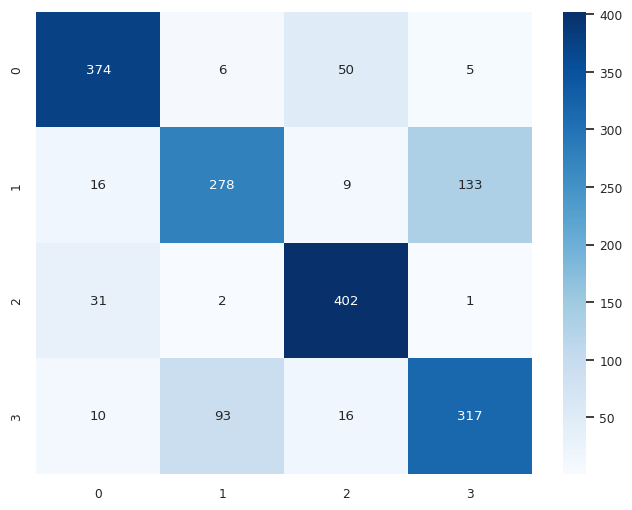

In [24]:
def load_kaggle_dataset(dataset_path):
    dataset = dict()
    for phase in ["train", "val", "test"]:
        phase_data = dataset_load(
            KaggleDatasetAdapter.HUGGING_FACE,
            dataset_path,
            f"{phase}.csv"
        )
        dataset[phase] = phase_data
    dataset = DatasetDict(dataset)
    print(f"Dataset loaded from {dataset_path} on Kaggle!\n")

    return dataset


def preprocess_function(tokeniser, example, text_column):
    examples = tokeniser(example[text_column], padding="max_length", truncation=True)
    return examples
    

def preprocess_dataset(dataset, tokeniser_model_name, text_column):
    tokeniser = AutoTokenizer.from_pretrained(tokeniser_model_name)
    dataset = dataset.map(lambda example: preprocess_function(tokeniser, example, text_column),
                          batched=True)
    
    if FINETUNING_METHOD == "regression":
        dataset = dataset.cast_column("labels", Value("float32"))
        
    print(f"Pre-processing completed with {tokeniser_model_name}!\n")
    print(dataset)

    return dataset, tokeniser
    

# Evaluating The Fine-Tuned Model
def evaluate_finetuned_model():
    # Load dataset from Kaggle
    dataset = load_kaggle_dataset(DATASET_PATH)

    # Tokenize and preprocess dataset
    dataset, _ = preprocess_dataset(dataset=dataset, tokeniser_model_name=FINETUNED_MODEL_REPO_ID, text_column="text")

    # Load fine-tuned model
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,              # Base model name
        num_labels=NUM_CLASSES)  # Set output layer size

    # Load PEFT/LoRA weights
    model = PeftModel.from_pretrained(model, FINETUNED_MODEL_REPO_ID)
    
    # Default training arguments for evaluation
    test_args = TrainingArguments(
        do_train=False,                    # No training
        do_predict=True,                   # Enable prediction
        per_device_eval_batch_size=16,     # Batch size for evaluation
        report_to="none")                  # Disable logging
    
    trainer = Trainer(
        model=model,                       # Model to evaluate
        args=test_args)                    # Evaluation arguments

    # Folder to save predictions and metrics
    folder_to_save = os.path.normpath(os.path.join(OUTPUTS_PATH, FINETUNED_MODEL_NAME))
    # Create folder if it doesn't exist
    os.makedirs(folder_to_save, exist_ok=True)

    # Select appropriate prediction function based on task
    if FINETUNING_METHOD == "regression":
        chosen_make_and_save_predictions = make_and_save_predictions_regression
    else:
        chosen_make_and_save_predictions = make_and_save_predictions_classification
        
    y_preds, y_test = chosen_make_and_save_predictions(
        trainer=trainer,                   # Trainer object
        test_dataset=dataset["test"],      # Test dataset
        folder_to_save=folder_to_save)     # Folder to save outputs

    # Compute and save evaluation metrics
    compute_and_save_eval_metrics(y_preds=y_preds, y_test=y_test, folder_to_save=folder_to_save)
    
# Execute evaluation
evaluate_finetuned_model()